# Kinematic Simulation of a Differential Drive Robot

# Introduction

Well what's a Differential Drive? It's basically a method used to move robots in which two independent wheels are mounted on a common axis. A differential is maintained between the two wheels.
* If both the wheels spin forward at the same time, the robot moves straight.
* If one spins faster than the other, it turns in the direction of the slower wheel.
* If they spin in opposite directions at the same speed, it spins **in place**.

# The Math (Most Important Part)

Alright so before simulating a Differential Drive Robot, we have to study the math behind it. Here are few things to keep in mind.

### Position
    First, off, we need the definition of position in 2D space for the robot.
    The position of the robot is given by the vector State = Transpose([x, y, theta])

### Input
    The input controls (commands to the robot) are -
    v: Linear Velocity (Forward Speed)
    w: Angular Velocity (Turning Speed)

### State Change
    The kinematic equations that describe how the state changes over time (x_dot, y_dot, theta_dot) based on our inputs are-
    
    x_dot = v * cos(theta)
    y_dot = v * sin(theta)
    theta_dot = w

# Defining the Robot Model

In [1]:
# First I'm just going to import necessary modules
import numpy as np
import matplotlib.pyplot as plt
import math

# Set up matplotlib for nice rendering in Jupyter
%matplotlib inline

In [2]:
# Now I'm going to write a function that updates the robot's pos based on velocity inputs
def update_state(x, y, theta, v, w, dt):
    # Just integrate state change equations to get these
    next_x = x + (v * math.cos(theta)) * dt
    next_y = y + (v * math.sin(theta)) * dt
    next_theta = theta + w * dt

    # But let's maintain the bijection, we don't want theta outside (-pi/2, pi/2)
    next_theta = math.atan2(math.sin(next_theta), math.cos(next_theta))

    return next_x, next_y, next_theta

# The Controller - The Brain

Now that I'm done making that function, the next thing I need to address is how the robot will know where the point is and approach it. For this a closed feedback loop will do the job. The robot needs to know two things at all times -
* How far it is from the goal
* Which distance it's facing and how to turn to face the goal

In [3]:
# This is a function to calculate the necessary input velocities to reach the goal
# Also, I'll be using just a Proportional Controller
def calculate_control_commands(x, y, theta, x_goal, y_goal):
    # Initialise Gains
    Kp_linear = 0.5
    Kp_angular = 2.0

    # First it needs to know distance from the goal
    distance_error = math.hypot(x-x_goal, y-y_goal)

    # Next it needs to know which direction to move in
    desired_heading = math.atan2(y_goal-y, x_goal-x)

    # Now it needs to know diffence in direction
    heading_error = desired_heading - theta
    heading_error = math.atan2(math.sin(heading_error), math.cos(heading_error))

    # Then generate the velocity commands
    v = Kp_linear * distance_error
    w = Kp_angular * heading_error

    # This is an extra thing I wanna add to simulate real world hardware limitations...
    # I'm going to cap the velocity at 1m/s
    v = min(v, 1.0)

    return v, w, distance_error

# Designing the Simulation Loop

Now that all this is done, we need to use these in a loop which ends when the robot reaches the end point.

In [4]:
# Initialise Conditions
x, y, theta = 0.0, 0.0, 0.0  # Starting at origin, facing right
x_goal, y_goal = 5.0, 5.0    # Target point

dt = 0.1 # Step duration of time
tolerance = 0.01 # Stop when we are within 0.1 meters of the goal

In [5]:
# Lists to store history for plotting
x_history = [x]
y_history = [y]

print("Starting simulation...")

while True:
    # Get commands from controller
    v, w, distance = calculate_control_commands(x, y, theta, x_goal, y_goal)
    
    # Check if we reached the goal
    if distance < tolerance:
        print("Goal Reached!")
        break
        
    # Update the robot's state
    x, y, theta = update_state(x, y, theta, v, w, dt)
    
    # Save history
    x_history.append(x)
    y_history.append(y)

Starting simulation...
Goal Reached!


I guess it's worked pretty well. Now I think it's better to look at it once so I'm going to try to plot it using matplotlib.

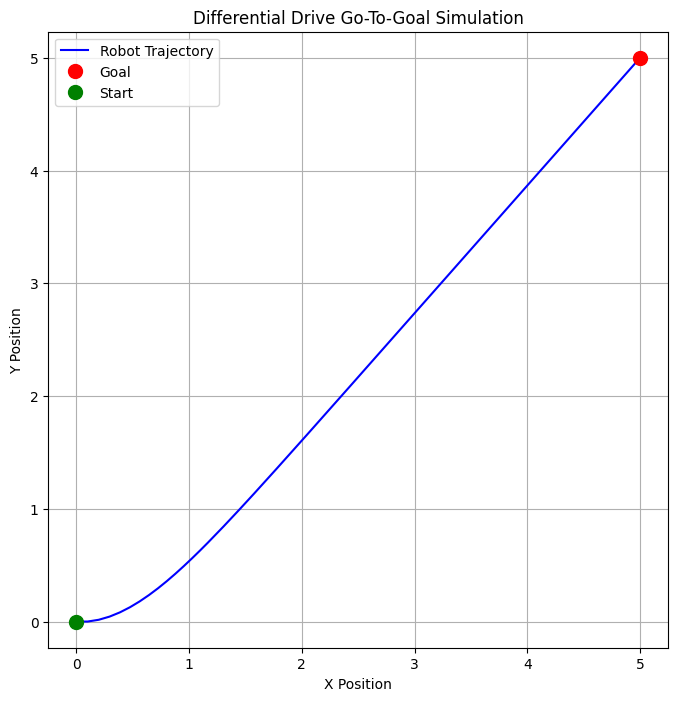

In [6]:
plt.figure(figsize=(8, 8))
plt.plot(x_history, y_history, label="Robot Trajectory", color='b')
plt.plot(x_goal, y_goal, 'ro', label="Goal", markersize=10)
plt.plot(0, 0, 'go', label="Start", markersize=10)

plt.title("Differential Drive Go-To-Goal Simulation")
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.grid(True)
plt.legend()
plt.axis('equal') # Ensures x and y scales are identical
plt.show()

# Custom Point Utilisation

I'm satisfied with the way this worked, so I'm going to extend it to use custom typed points, and initial direction.

Enter tuples with comma-separation


Enter Initial Coordinates:  0, 0
Enter Theta Value:  1.57
Enter Final Coordinates:  4, -4


Starting simulation...
Goal Reached!


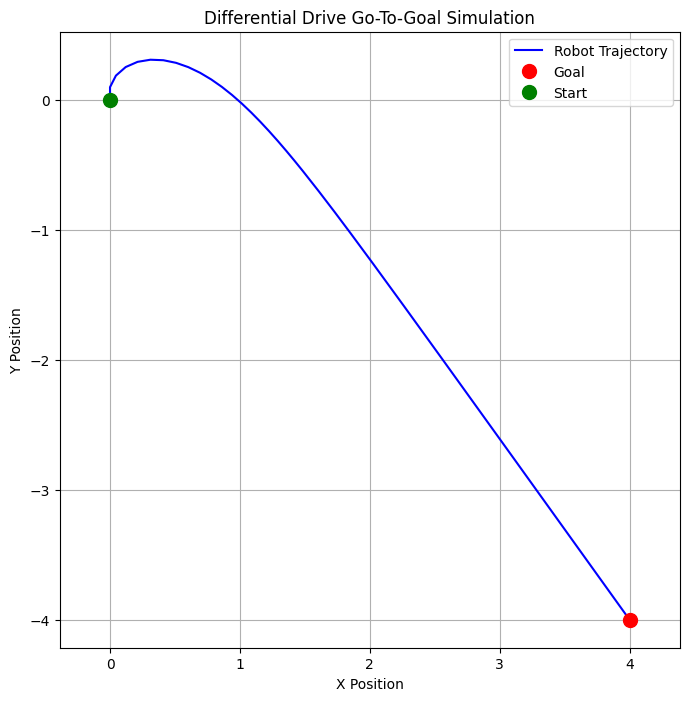

Enter tuples with comma-separation


Enter Initial Coordinates:  3, 3
Enter Theta Value:  0
Enter Final Coordinates:  -2, 0


Starting simulation...
Goal Reached!


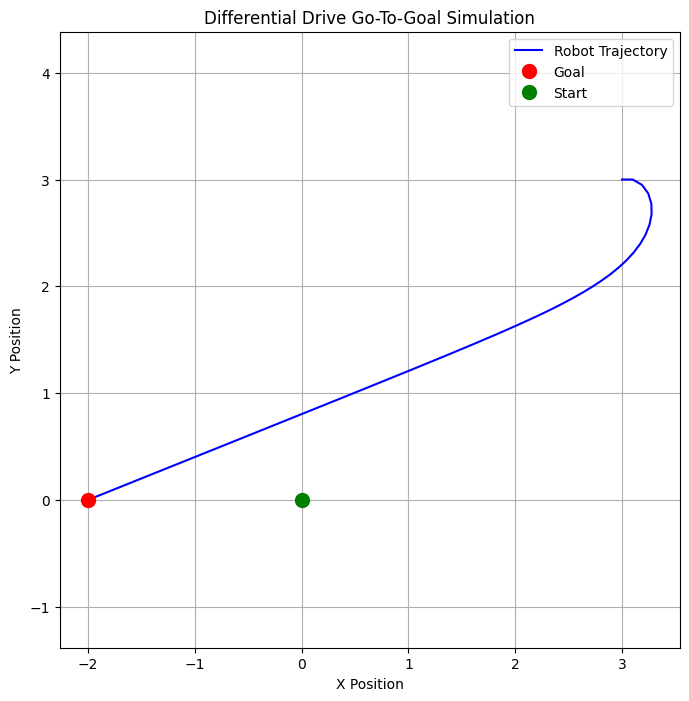

Enter tuples with comma-separation


Enter Initial Coordinates:  0, -1
Enter Theta Value:  -2.35
Enter Final Coordinates:  2, 0


Starting simulation...
Goal Reached!


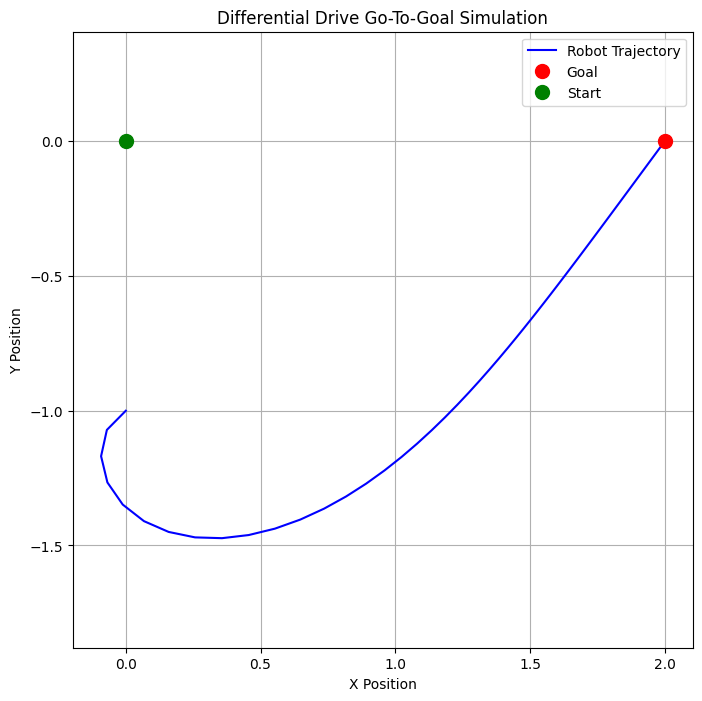

In [7]:
for i in range(3):
    print("Enter tuples with comma-separation")
    coord = input("Enter Initial Coordinates: ")
    (x, y) = coord.split(",")
    x, y = float(x.strip()), float(y.strip())

    theta = float(input("Enter Theta Value: "))
    theta = math.atan2(math.sin(theta), math.cos(theta))

    coord_goal = input("Enter Final Coordinates: ")
    (x_goal, y_goal) = coord_goal.split(",")
    x_goal, y_goal = float(x_goal.strip()), float(y_goal.strip())
    
    x_history = [x]
    y_history = [y]
    
    print("Starting simulation...")
    
    while True:
        v, w, distance = calculate_control_commands(x, y, theta, x_goal, y_goal)
        
        if distance < tolerance:
            print("Goal Reached!")
            break
            
        x, y, theta = update_state(x, y, theta, v, w, dt)
        
        x_history.append(x)
        y_history.append(y)

    plt.figure(figsize=(8, 8))
    plt.plot(x_history, y_history, label="Robot Trajectory", color='b')
    plt.plot(x_goal, y_goal, 'ro', label="Goal", markersize=10)
    plt.plot(0, 0, 'go', label="Start", markersize=10)
    
    plt.title("Differential Drive Go-To-Goal Simulation")
    plt.xlabel("X Position")
    plt.ylabel("Y Position")
    plt.grid(True)
    plt.legend()
    plt.axis('equal') # Ensures x and y scales are identical
    plt.show()

Alright now that we've seen it doing pretty cool stuff, I think we could even try doing it wheel-wise. I mean to say - writing equations for each wheel's rpm etc based on direction error etc. Otherwise this just looks like path-planning which isn't what we're trying to do here, although they're related. Sp yeah agin for this we need to find the rpm using v and w, which uses Inverse Kinematics.

# The Math (Diff. Drive Inverse Kinematics)

To translate theoretical control to physical wheels, we need two physical measurements of the robot:
* `L`: The Track Width (distance between the two wheels).
* `R`: The Wheel Radius.

First, we figure out how fast the wheels need to move along the ground.
* If the robot is moving straight at velocity **v**, both wheels move at **v**.
* If the robot is spinning in place at angular velocity ***w***, the wheels must push in opposite directions. The speed of the wheel is proportional to half the track width (*L/2*).

So now we get the required speeds as
* v_R = v + wL/2
* v_L = v - wL/2
(Remember that the w we're taking is anticlockwise - by convention)

But wheels don't take linear speeds as input, they need angular speeds. Let's denote angular speeds of wheels using phi.
* phi_R = v_R/R = (v + wL/2)/R
* phi_L = v_L/R = (v - wL/2)/R

This is the Mathematical Part, next is just the code.

In [8]:
# I'm just writing a function to convert theoretical velocities into individual rotary speeds
def calculate_wheel_speeds(v, omega, L, R):
    # Calculate linear speed of each wheel along the ground
    v_right = v + (omega * L / 2.0)
    v_left = v - (omega * L / 2.0)
    
    # Convert linear ground speed to rotational speed of the wheel
    phi_right = v_right / R
    phi_left = v_left / R
    
    return phi_left, phi_right

In [11]:
# Reinitialise
x, y, theta = 0.0, 0.0, 0.0
x_goal, y_goal = 5.0, 5.0

# Physical Constraints
L = 0.5  # Distance between wheels in meters
R = 0.1  # Wheel radius in meters

# Lists to store wheel speeds for plotting later
phi_l_history = []
phi_r_history = []

while True:
    # Get theoretical commands from controller
    v, w, distance = calculate_control_commands(x, y, theta, x_goal, y_goal)
    
    # Convert to wheel speeds
    phi_left, phi_right = calculate_wheel_speeds(v, w, L, R)
    
    # Save wheel speeds to see what the motors are actually doing
    phi_l_history.append(phi_left)
    phi_r_history.append(phi_right)
    
    # Check if we reached the goal
    if distance < tolerance:
        print("Goal Reached!")
        break
        
    # Update the robot's state (Still using v and omega for the math update)
    x, y, theta = update_state(x, y, theta, v, w, dt)
    
    # Save position history...

Goal Reached!


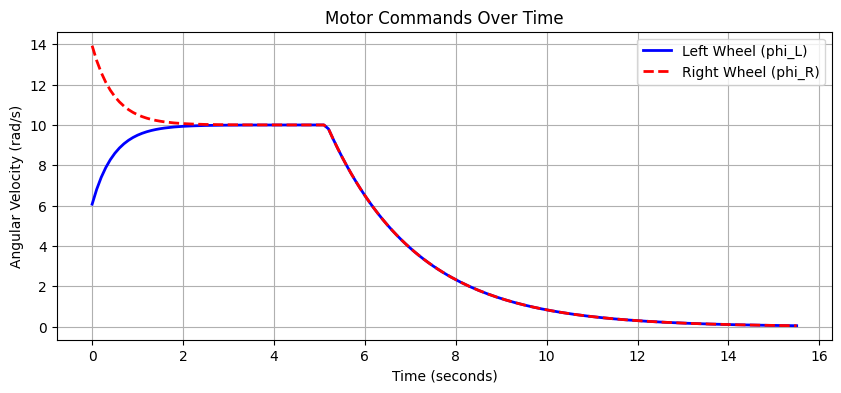

In [12]:
# Now I want to basically visualise what my simulation is doing
time_steps = np.arange(len(phi_l_history)) * dt

plt.figure(figsize=(10, 4))

# Plot left and right wheel speeds
plt.plot(time_steps, phi_l_history, label="Left Wheel (phi_L)", color='blue', linewidth=2)
plt.plot(time_steps, phi_r_history, label="Right Wheel (phi_R)", color='red', linestyle='--', linewidth=2)

plt.title("Motor Commands Over Time")
plt.xlabel("Time (seconds)")
plt.ylabel("Angular Velocity (rad/s)")
plt.grid(True)
plt.legend()
plt.show()

# Side-By-Side Plot
I'm pretty convinced with this, but to show what is happening I want to plot the earlier plot and the above plot side by side for the same set of initial and ending values.

Starting simulation...
Goal Reached!


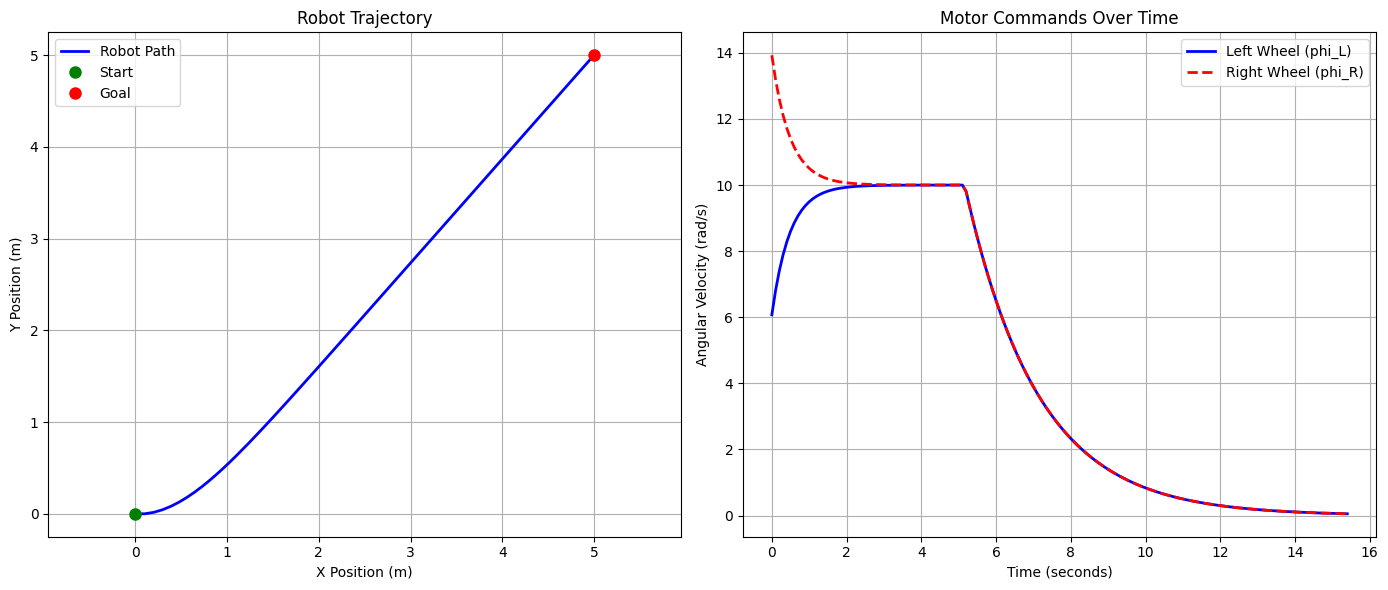

In [14]:
# Reinitialise
x, y, theta = 0.0, 0.0, 0.0
x_goal, y_goal = 5.0, 5.0

# Physical Constraints
L = 0.5  # Distance between wheels in meters
R = 0.1  # Wheel radius in meters

# Lists to store wheel speeds and coordinate histories for plotting later
phi_l_history = []
phi_r_history = []

x_history = [x]
y_history = [y]

print("Starting simulation...")

while True:
    v, w, distance = calculate_control_commands(x, y, theta, x_goal, y_goal)
    phi_left, phi_right = calculate_wheel_speeds(v, w, L, R)
    
    if distance < tolerance:
        print("Goal Reached!")
        break
        
    x, y, theta = update_state(x, y, theta, v, w, dt)
    
    x_history.append(x)
    y_history.append(y)
    phi_l_history.append(phi_left)
    phi_r_history.append(phi_right)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: The Robot's Path (Left)
ax1.plot(x_history, y_history, label="Robot Path", color='blue', linewidth=2)
ax1.plot(0, 0, 'go', label="Start", markersize=8)
ax1.plot(x_goal, y_goal, 'ro', label="Goal", markersize=8)

ax1.set_title("Robot Trajectory")
ax1.set_xlabel("X Position (m)")
ax1.set_ylabel("Y Position (m)")
ax1.axis('equal') # Forces the X and Y axes to have the same scale
ax1.grid(True)
ax1.legend()

# Plot 2: The Motor Commands (Right)
time_steps = np.arange(len(phi_l_history)) * dt
    
ax2.plot(time_steps, phi_l_history, label="Left Wheel (phi_L)", color='blue', linewidth=2)
ax2.plot(time_steps, phi_r_history, label="Right Wheel (phi_R)", color='red', linestyle='--', linewidth=2)

ax2.set_title("Motor Commands Over Time")
ax2.set_xlabel("Time (seconds)")
ax2.set_ylabel("Angular Velocity (rad/s)")
ax2.grid(True)
ax2.legend()

# Automatically adjusts spacing so titles and labels don't overlap
plt.tight_layout() 
plt.show()

## How to Read the Right Graph Against Left

* ***When the lines overlap perfectly:*** The left and right wheels are moving at the exact same speed. The robot is driving perfectly straight.
* ***When the lines separate:*** The robot is turning.
  * If the Left Wheel line is higher than the Right Wheel line, the robot is turning Right.
  * If the Right Wheel line is higher, the robot is turning Left.
* ***When the lines cross the zero axis:*** A wheel is spinning backward. If one is positive and the other is negative by the same amount, the robot is spinning in place!
* ***The ramp-down at the end:*** Because we used a Proportional Controller ($v = K_p \times \text{distance}$), we can see both lines smoothly curve down toward zero as the robot approaches the target and slows itself down to a stop.